# 01 - EDA Dataset Overview

Mục tiêu của giai đoạn này là kiểm tra tổng quan bộ dữ liệu trước khi đi sâu vào chất lượng annotation. Pipeline của notebook gồm:
Kết nối với Googdle Drive và cấu hình dataset.
Kiểm tra cấu trúc train/valid/test.
Phân tích kích thước hình ảnh.
Thống kê số lượng ảnh và bounding box theo từng tập.
Sau đó quan sát phân bố lớp của toàn bộ dataset theo từng split.

Import thư viện và Kết nối tới Drive

In [1]:
# kết nối tới drive
from google.colab import drive
drive.mount("/content/drive")
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import numpy as np

from PIL import Image

sns.set_theme(style="whitegrid")

DATA_DIR = Path("/content/drive/MyDrive/SelfProject/HDIRLT/datasource")
DATA_YAML = DATA_DIR / "data.yaml" # file caasu hinh data

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

print("Đường dẫn dataset: ", DATA_DIR)

class_names = data_config["names"]
num_classes = data_config["nc"]

Mounted at /content/drive
Đường dẫn dataset:  /content/drive/MyDrive/SelfProject/HDIRLT/datasource


Số lớp và tên lớp


In [2]:
print("Số lớp: ", num_classes)
print("Tên lớp: ", class_names)

Số lớp:  6
Tên lớp:  ['bike', 'helmet', 'lisc', 'no_helmet', 'noise', 'rider']


Kiểm tra

In [3]:
splits = ["train", "valid", "test"]

for split in splits:
  # tách image và label
  image_dir = DATA_DIR / split / "images"
  label_dir = DATA_DIR / split / "labels"

  print(f"{split}:")
  print(" - Images: ",image_dir)
  print(" - Labels: ",label_dir)
  print(" - Tồn tại images: ",image_dir.exists())
  print(" - tồn tại labels: ",label_dir.exists())

train:
 - Images:  /content/drive/MyDrive/SelfProject/HDIRLT/datasource/train/images
 - Labels:  /content/drive/MyDrive/SelfProject/HDIRLT/datasource/train/labels
 - Tồn tại images:  True
 - tồn tại labels:  True
valid:
 - Images:  /content/drive/MyDrive/SelfProject/HDIRLT/datasource/valid/images
 - Labels:  /content/drive/MyDrive/SelfProject/HDIRLT/datasource/valid/labels
 - Tồn tại images:  True
 - tồn tại labels:  True
test:
 - Images:  /content/drive/MyDrive/SelfProject/HDIRLT/datasource/test/images
 - Labels:  /content/drive/MyDrive/SelfProject/HDIRLT/datasource/test/labels
 - Tồn tại images:  True
 - tồn tại labels:  True


# Kiểm tra kích thước ảnh

Phần này tập trung trả lời 3 câu hỏi chính:
1. Dataset có những kích thước ảnh nào?
2. Có ảnh quá nhỏ hoặc aspect ratio quá lạ không?
3. Train/val/test có khác nhau nhiều về image size không?

In [5]:
image_size_records = []
'''
Kiểm tra kích thước ảnh từng split
'''

for split in splits:
  image_dir = DATA_DIR / split / "images"

  image_files = (
      list(image_dir.glob("*.jpg"))
      + list(image_dir.glob("*.png"))
      + list(image_dir.glob("*.jpeg"))
  )

  for image_file in image_files:
    # mở ảnh để lấy W và H
    with Image.open(image_file) as img:
      width, height = img.size
    # lưu thông tin kích thước ảnh
    image_size_records.append({
        "split": split,
        "image_file": image_file.name,
        "width": width,
        "height": height,
        "aspect_ratio": width / height
    })

# dataframe lưu size của dataset
image_size_df = pd.DataFrame(image_size_records)

image_size_df.head()

,split,image_file,width,height,aspect_ratio
0,train,27781_jpg.rf.3479bcf6a613a43254f0ceea845272f1.jpg,1024,1024,1.0
1,train,28108_jpg.rf.12e1336618269f6053ff80296202f858.jpg,1024,1024,1.0
2,train,23502_jpg.rf.d64b867b20be5d882d5f60242aff08d6.jpg,1024,1024,1.0
3,train,22106_jpg.rf.fec2351a46535c55d20d3a5f444cc877.jpg,1024,1024,1.0
4,train,30099_jpg.rf.f818a9d95d6af75b71d97713d5bc0dd1.jpg,1024,1024,1.0


Kiểm tra toàn bộ dataset có những kích thước ảnh nào

In [7]:
image_size_summary = (
    image_size_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="num_images")
    .sort_values("num_images", ascending=False)
)

image_size_summary

,width,height,num_images
0,1024,1024,2121


SỬ DỤNG PHƯƠNG PHÁP IQR ĐỂ KIỂM TRA OUTLIERS

In [8]:
def find_iqr_outliers(df, column):
  # Q1 là móc 25% của dữ liệu
  q1 = df[column].quantile(0.25)

  #Q3 là mốc 75% của dữ liệu
  q3 = df[column].quantile(0.75)

  # IQR thể hiện khaongr dao động chính của dữ liệu
  iqr = q3 - q1

  # Giá trị nhỏ hơn lower_bound hoặc lớn hơn upper bound được xem là outliers
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr

  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
  return outliers, lower_bound, upper_bound


In [9]:
# Tìm ảnh bất thường theo width
width_outliers, width_lower, width_upper = find_iqr_outliers(image_size_df, "width")

# Tìm ảnh bất thường theo height
height_outliers, height_lower, height_upper = find_iqr_outliers(image_size_df, "height")

# Tìm ảnh bất thường theo aspect ratio
aspect_ratio_outliers, ar_lower, ar_upper = find_iqr_outliers(image_size_df, "aspect_ratio")

print("Ngưỡng width theo IQR:")
print(f"- Lower: {width_lower}")
print(f"- Upper: {width_upper}")
print("Số ảnh có width bất thường:", len(width_outliers))

print("\nNgưỡng height theo IQR:")
print(f"- Lower: {height_lower}")
print(f"- Upper: {height_upper}")
print("Số ảnh có height bất thường:", len(height_outliers))

print("\nNgưỡng aspect ratio theo IQR:")
print(f"- Lower: {ar_lower}")
print(f"- Upper: {ar_upper}")
print("Số ảnh có aspect ratio bất thường:", len(aspect_ratio_outliers))

Ngưỡng width theo IQR:
- Lower: 1024.0
- Upper: 1024.0
Số ảnh có width bất thường: 0

Ngưỡng height theo IQR:
- Lower: 1024.0
- Upper: 1024.0
Số ảnh có height bất thường: 0

Ngưỡng aspect ratio theo IQR:
- Lower: 1.0
- Upper: 1.0
Số ảnh có aspect ratio bất thường: 0


Train/val/test có khác nhau về image size không

In [10]:
split_image_size_summary = (
    image_size_df
    .groupby(["split", "width", "height"])
    .size()
    .reset_index(name="num_images")
    .sort_values(["split", "num_images"], ascending=[True, False])
)

split_image_size_summary

,split,width,height,num_images
0,test,1024,1024,260
1,train,1024,1024,1462
2,valid,1024,1024,399


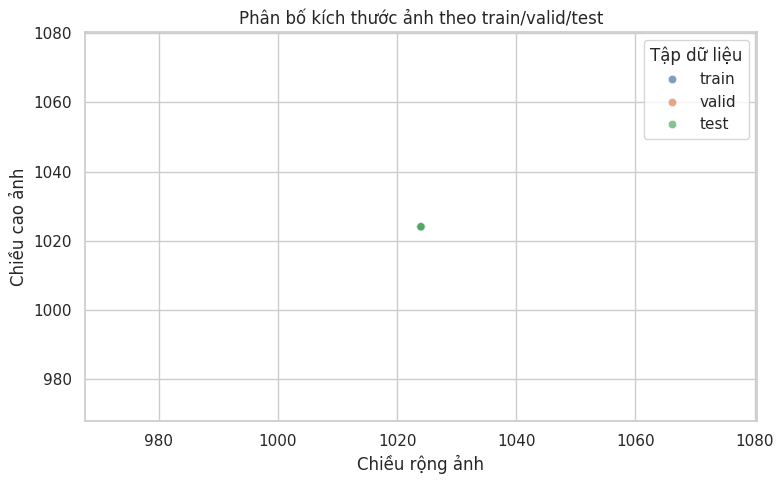

In [11]:
plt.figure(figsize=(8, 5))

ax = sns.scatterplot(
    data=image_size_df,
    x="width",
    y="height",
    hue="split",
    alpha=0.7
)

plt.title("Phân bố kích thước ảnh theo train/valid/test")
plt.xlabel("Chiều rộng ảnh")
plt.ylabel("Chiều cao ảnh")
plt.legend(title="Tập dữ liệu")

plt.tight_layout()
plt.show()

# Đếm số ảnh và bounding box trong train/val/test

In [12]:
summary_rows = []
bbox_records = []

for split in splits:
  image_dir = DATA_DIR / split / "images"
  label_dir = DATA_DIR / split / "labels"

  image_files = (
      list(image_dir.glob("*.jpg"))
      + list(image_dir.glob("*.png"))
      + list(image_dir.glob("*.jpeg"))
  ) # take all image type

  label_files = list(label_dir.glob("*.txt"))

  total_bboxes = 0
  empty_label_files = 0

  for label_file in label_files:
      # Mỗi ảnh trong YOLO thường có một file .txt tương ứng chứa annotation.
      # Vòng lặp này đọc lần lượt từng file label để lấy các bounding box.
      with open(label_file, "r", encoding="utf-8") as f:
          # Mỗi dòng trong file label là một bounding box.
          # line.strip() dùng để bỏ khoảng trắng/thừa xuống dòng.
          # if line.strip() giúp bỏ qua các dòng rỗng nếu có.
          lines = [line.strip() for line in f.readlines() if line.strip()]

      if len(lines) == 0:
        empty_label_files += 1

      for line in lines:
        parts = line.split()
        class_id = int(parts[0])

        total_bboxes += 1

        bbox_records.append({
            "split": split,
            "class_id": class_id,
            "class_name": class_names[class_id],
            "label_file": label_file.name
        })

  summary_rows.append({
     "split": split,
      "num_images": len(image_files),
      "num_label_files": len(label_files),
      "num_bboxes": total_bboxes,
      "empty_label_files": empty_label_files,
      "avg_bboxes_per_image": total_bboxes / len(image_files) if len(image_files) > 0 else 0
  })

summary_df = pd.DataFrame(summary_rows)
bbox_df = pd.DataFrame(bbox_records)

summary_df

,split,num_images,num_label_files,num_bboxes,empty_label_files,avg_bboxes_per_image
0,train,1462,1462,16013,2,10.952804
1,valid,399,399,4221,0,10.578947
2,test,260,260,2992,0,11.507692


# Thống kê phân bố lớp toàn bộ dataset

--> Kiểm tra xem các lớp trong dataset là gì

In [14]:
class_distribution = (
    bbox_df
    .groupby(["class_id", "class_name"])
    .size()
    .reset_index(name="num_bboxes")
    .sort_values("num_bboxes", ascending=False)
)

class_distribution

,class_id,class_name,num_bboxes
5,5,rider,6366
0,0,bike,5545
2,2,lisc,4195
3,3,no_helmet,3191
1,1,helmet,2910
4,4,noise,1019


Biểu đồ cột class distribution - Kiểm tra lớp nhiều nhất và lớp ít nhất

/tmp/ipykernel_3334/1992588192.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


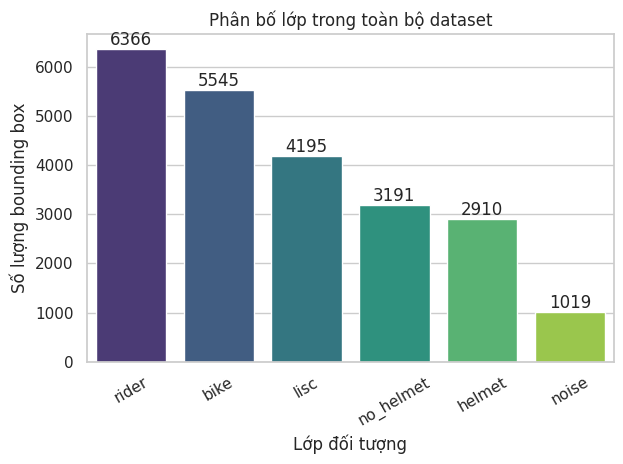

In [15]:
ax = sns.barplot(
    data = class_distribution,
    x = "class_name",
    y = "num_bboxes",
    palette = "viridis"
)

plt.title("Phân bố lớp trong toàn bộ dataset")
plt.xlabel("Lớp đối tượng")
plt.ylabel("Số lượng bounding box")
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Phân bố lớp theo từng tập train/val/test

--> Kiểm tra dữ liệu riêng lẻ từng lớp

In [16]:
# Kiểm tra bbox_df hiện đang có những split nào
bbox_df["split"].value_counts()

,count
split,
train,16013
valid,4221
test,2992


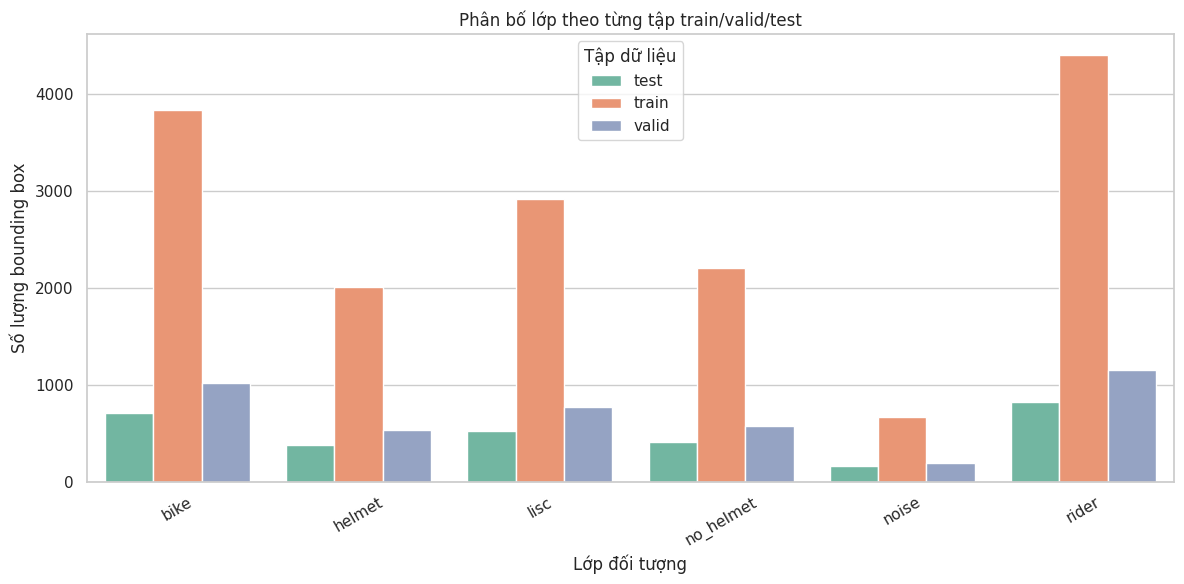

,split,class_name,num_bboxes
0,test,bike,702
1,test,helmet,379
2,test,lisc,520
3,test,no_helmet,411
4,test,noise,162
5,test,rider,818
6,train,bike,3832
7,train,helmet,2003
8,train,lisc,2910
9,train,no_helmet,2204


In [17]:
split_class_distribution = (
    bbox_df
    .groupby(["split", "class_name"])
    .size()
    .reset_index(name="num_bboxes")
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=split_class_distribution,
    x="class_name",
    y="num_bboxes",
    hue="split",
    palette="Set2"
)

plt.title("Phân bố lớp theo từng tập train/valid/test")
plt.xlabel("Lớp đối tượng")
plt.ylabel("Số lượng bounding box")
plt.xticks(rotation=30)
plt.legend(title="Tập dữ liệu")

plt.tight_layout()
plt.show()

split_class_distribution